# PRIMA PROVA DI NEURAL NETWORK

### importazioni

In [ ]:
import sys
sys.path.append("../ML_app")

from neural_network_numba import SGD_algorithm, neural_predict
from cost_functions import sigmoide

In [2]:
import pickle as pkl
import numpy as np

with open('data/ottani_NIR.pkl', 'rb') as f:
    dizionario = pkl.load(f)
    
# dati train
train_ones = dizionario['train']['NIR']['ones']
train_zeros = dizionario['train']['NIR']['zeros']
train_labels = dizionario['train']['labels']
train_x = np.concatenate((train_zeros, train_ones))

# dati test
test_ones = dizionario['test']['NIR']['ones']
test_zeros = dizionario['test']['NIR']['zeros']
test_labels = dizionario['test']['labels']
test_x = np.concatenate((test_zeros, test_ones))

In [3]:
'''
SGD_algorithm(
    weights: np.ndarray, 
    inputs: np.ndarray,
    expected_output: np.ndarray,
    learning_rate: float = 0.9,
)
'''
# inputs sono i train_x, expected outputs sono i train_labels

'\nSGD_algorithm(\n    weights: np.ndarray, \n    inputs: np.ndarray,\n    expected_output: np.ndarray,\n    learning_rate: float = 0.9,\n)\n'

## SENZA PCA

In [4]:
# inizializzazione weights
N = train_x.shape[1]
weights = np.random.rand(N)

In [5]:
weights

array([0.90395133, 0.27501194, 0.09497816, 0.48120703, 0.23183729,
       0.95254956, 0.67709397, 0.65275612, 0.85472785, 0.33249356,
       0.75507011, 0.51527243, 0.79021859, 0.87872806, 0.94193595,
       0.65499909, 0.48533928, 0.43276453, 0.92719288, 0.29680282,
       0.93459126, 0.22094651, 0.22821033, 0.84044517, 0.34566043,
       0.30492327, 0.41967291, 0.91119302, 0.42311953, 0.06161173,
       0.11011112, 0.33312905, 0.65009022, 0.45493781, 0.12479331,
       0.79202726, 0.14946906, 0.01881509, 0.95978011, 0.12087851,
       0.39885064, 0.14890598, 0.72083039, 0.22045911, 0.23449242,
       0.40682104, 0.56749749, 0.31574178, 0.16484431, 0.25396561,
       0.03227709, 0.8368518 , 0.59182101, 0.81875716, 0.77310616,
       0.71911092, 0.03424645, 0.63096069, 0.71620896, 0.19607274,
       0.75678475, 0.39575696, 0.4723962 , 0.22313919, 0.27855661,
       0.09255488, 0.48401266, 0.48708806, 0.39428327, 0.92159007,
       0.48081934, 0.27201821, 0.68224498, 0.35463494, 0.89553

### normalizzazione

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = MinMaxScaler()
train_x = scaler.fit_transform(train_x, train_labels)
test_x = scaler.transform(test_x)

### training

### testing

---

## neural network con PCA

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=7)
train_x_pca = pca.fit_transform(train_x, train_labels)

### training

In [8]:
# inizializzo weights nuovi
N_pca = train_x_pca.shape[1]
weights_pca = np.random.rand(N_pca)

In [9]:
epoche = 10_000

lista_errori_medi = []
lista_ultimi_erorri = []
lista_std_errori = []
lista_tutti_errori = np.ones(1)

for i in range(epoche):
    weights_pca, errori = SGD_algorithm(
        weights_pca,
        train_x_pca,
        train_labels,
        learning_rate = 0.9
    )
    
    lista_errori_medi.append(np.mean(errori))
    lista_ultimi_erorri.append(errori[-1])
    lista_std_errori.append(np.std(errori))
    lista_tutti_errori = np.concatenate((lista_tutti_errori, errori))


Text(0, 0.5, 'MSE al termine epoca')

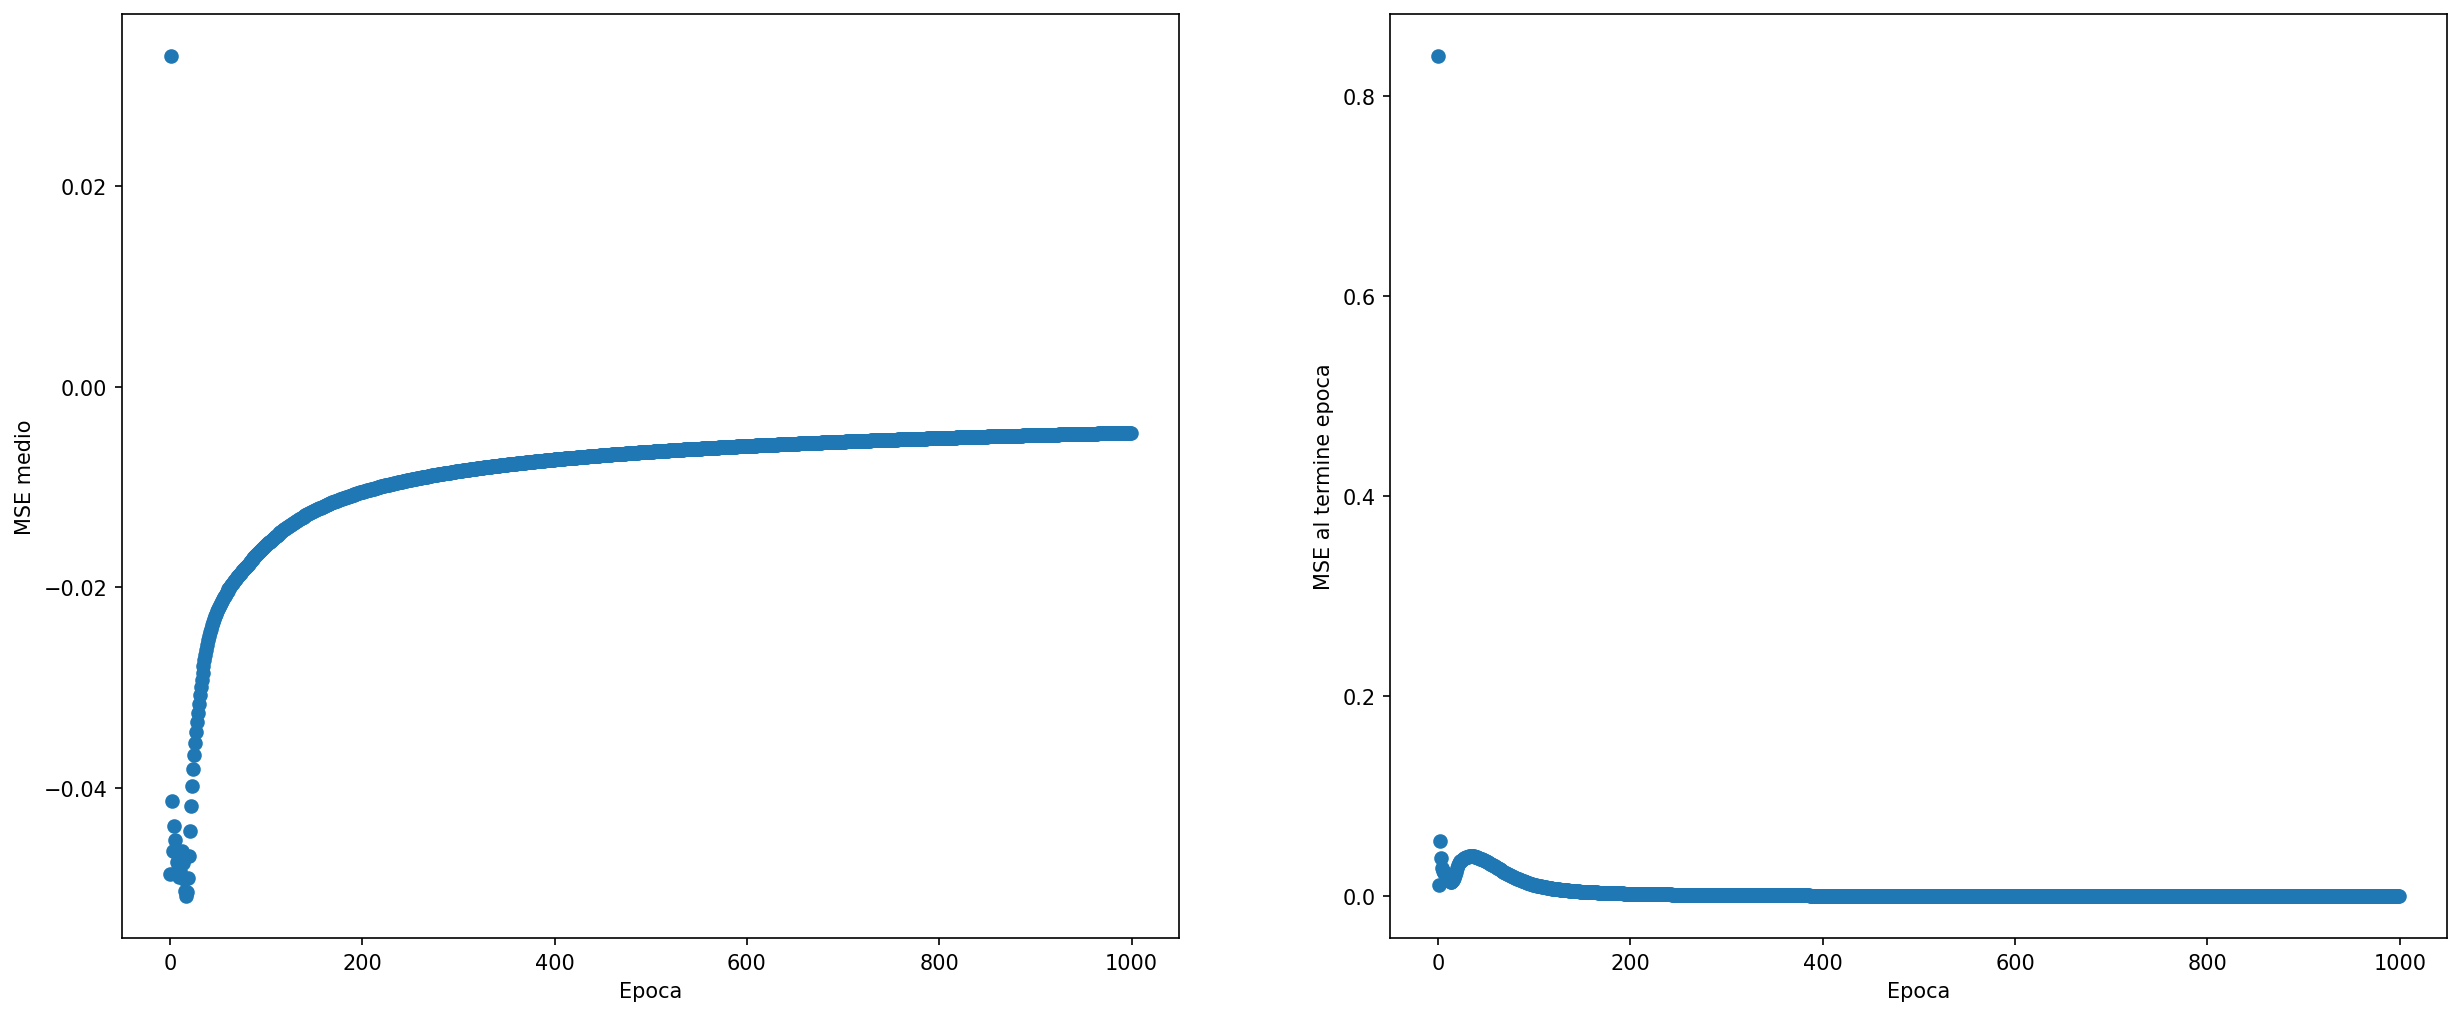

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(20, 8), dpi=150)

x = range(np.array(lista_errori_medi).shape[0])[:1000]
y1 = np.array(lista_errori_medi)[:1000]
y2 = np.array(lista_ultimi_erorri)[:1000]

#plt.errorbar(x, y, yerr=lista_std_errori)
ax[0].scatter(x,y1)
ax[0].set_xlabel("Epoca")
ax[0].set_ylabel("MSE medio")

ax[1].scatter(x,y2)
ax[1].set_xlabel("Epoca")
ax[1].set_ylabel("MSE al termine epoca")

Text(0, 0.5, 'MSE')

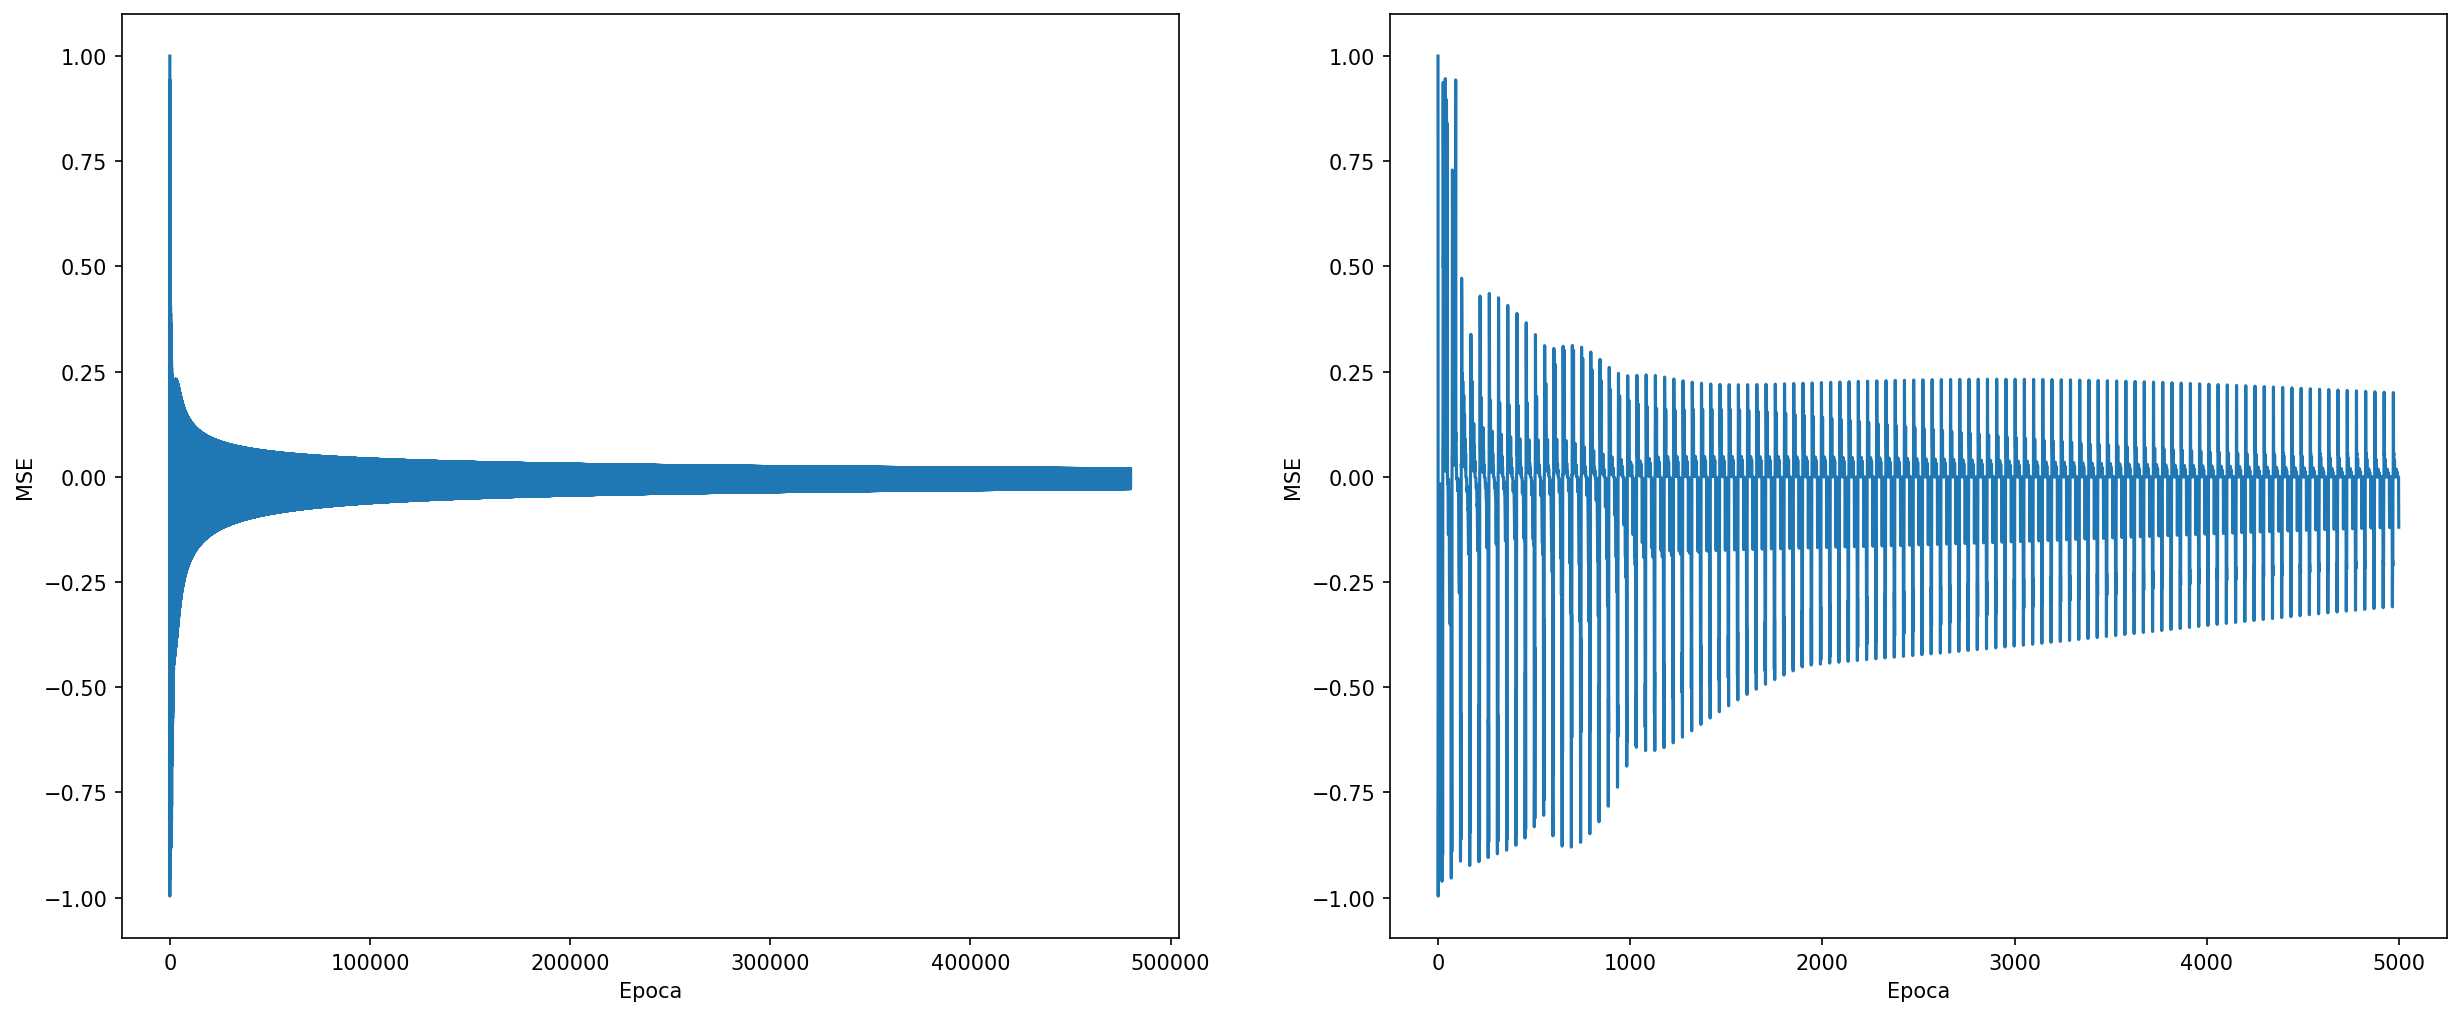

In [23]:
x1 = range(np.array(lista_tutti_errori).shape[0])
y1 = np.array(lista_tutti_errori)
x2 = x1[:5000]
y2 = y1[:5000]

fig, ax = plt.subplots(1, 2, figsize=(20, 8), dpi=150)

ax[0].plot(x1,y1)
ax[0].set_xlabel("Epoca")
ax[0].set_ylabel("MSE")

ax[1].plot(x2,y2)
ax[1].set_xlabel("Epoca")
ax[1].set_ylabel("MSE")

### test

In [12]:
test_x_pca = pca.transform(test_x)

In [13]:
prediction = neural_predict(
    weights_pca,
    test_x_pca
)

In [14]:
prediction

array([0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0.])